## 6.1

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE             = True
BITPIX             = 16
NAXIS              = 2
NAXIS1             = 530
NAXIS2             = 530
EXTEND             = True
shape: (530, 530)
>i2

Min value:1507 
Max value: 15752
Mean: 4795.924268422927
Standard deviation: 1848.2526085366376
Median: 4102.0
Mode: 3551


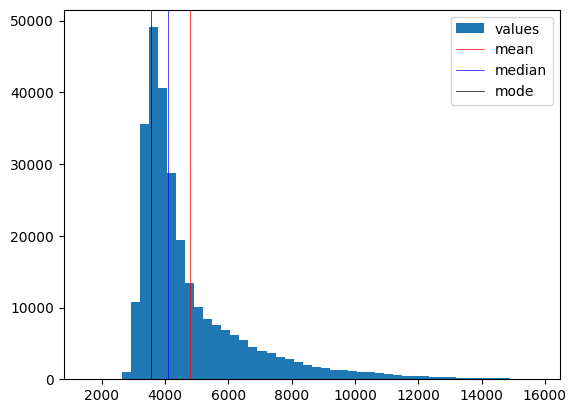

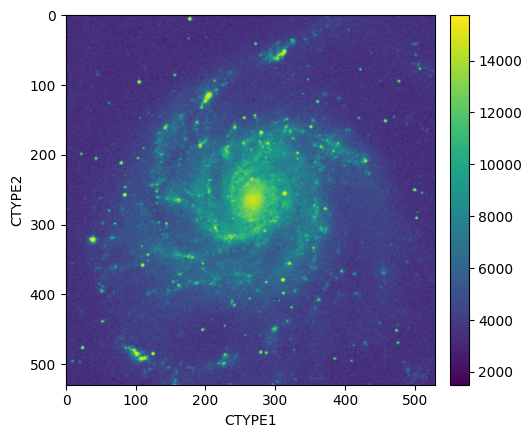

In [97]:
import numpy as np
from astropy.io import fits
from scipy.stats import mode
from matplotlib.pyplot import figure, show
from matplotlib.pyplot import subplots, show
from mpl_toolkits.axes_grid1 import make_axes_locatable


#header stores metadata (instrument, observation date, sky coordinates)
#data stores measurements, images, etc

hdulist = fits.open("m101.fits")
hdulist.info()
hdr = hdulist[0].header
for key in hdr[:6]:
    print(f"{key:18s} = {hdr[key]}")
    
dat = hdulist[0].data
print("shape:" ,(hdr["NAXIS2"],hdr["NAXIS1"]))

print(dat.dtype)

data_table = dat.flatten()
mode,counts = mode(data_table)
median = np.median(data_table)
print(f"""
Min value:{data_table.min()} 
Max value: {data_table.max()}
Mean: {np.mean(data_table)}
Standard deviation: {np.std(data_table)}
Median: {np.median(data_table)}
Mode: {mode}""")

from matplotlib.pyplot import figure, show
fig = figure()
frame = fig.add_subplot()

frame.hist(data_table,bins = 50,label="values")
frame.axvline(np.mean(data_table), color="r",linewidth=0.5,label="mean")
frame.axvline(median, color="b",linewidth=0.5,label="median")
frame.axvline(mode, color="k",linewidth=0.5,label="mode")
frame.legend()

show()
dat_point = np.asarray(dat)

fig = figure()
frame1 = fig.add_subplot()
frame1.imshow(dat_point,interpolation="none",origin = "lower",cmap="jet",vmin=median)

divider=make_axes_locatable(frame1)
cbarframe = divider.append_axes("right", size="5%", pad=0.15)
mappable = frame1.imshow(dat.T)
cbar = fig.colorbar(mappable,cax=cbarframe)


frame1.set_xlabel("CTYPE1")
frame1.set_ylabel("CTYPE2")
show()
hdr.set('BUNIT', 'Counts')
hdulist.writeto('m101_new.fits', overwrite=True, output_verify='ignore')
hdulist.close()


It has two HDU's? Primary and Photometric Caltable? \
The primary one has an image because its dimensions are 530,530\
Number type is 16 bit integer\
BITPIX = 16, number type is 16 bits. makes sense \
Shape is 530 by 530 (same like dimensions) \
dtype is greater than i2, which is integers; BITPIX is also integers\
2 means 2 bytes, 1 byte is 8 bits

## 6.3

6.644608785827525
mean = 4795.924268422927, standard deviation = 1848.2526085366376
[3567 3567 3567 ... 3099 3446 3446]


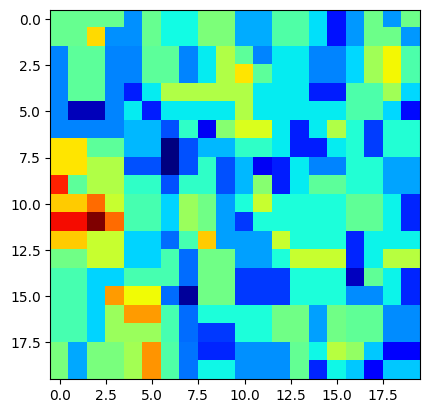

In [81]:
import numpy as np
from astropy.io import fits
from scipy.stats import mode
from matplotlib.pyplot import figure, show
from matplotlib.pyplot import subplots, show
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdulist = fits.open("m101.fits")
hdr = hdulist[0].header

dat = hdulist[0].data

sliced_dat = dat[0:20,0:20]

fig = figure()
frame = fig.add_subplot()
frame.imshow(sliced,interpolation="none",origin = "upper",cmap="jet")

flatdat = dat.flatten()
rms = np.sqrt(1/len(flatdat)*np.sum(np.square(flatdat)))
print(rms)
mean = np.mean(flatdat)
std = np.std(flatdat)
print(f"mean = {mean}, standard deviation = {std}")
print(flatdat)

standard deviation includes the difference of the mean and point squared, rms does not inlcude mean.
rms quantifies it best because it gives the value of the noise; standard deviation just says how strong the noise might be?

## 6.5

standard deviation of the mean is: 5.773191380233297
rms of mean is: 5.773192609220416


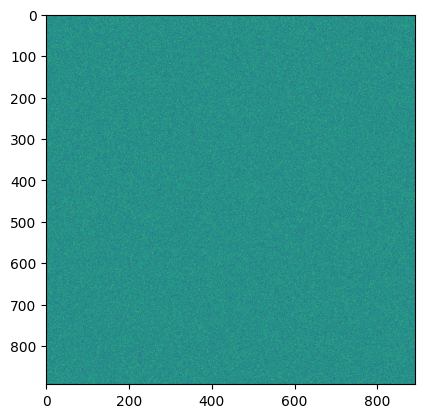

In [112]:
import numpy as np
from astropy.io import fits
from scipy.stats import mode
from matplotlib.pyplot import figure, show
from matplotlib.pyplot import subplots, show
from mpl_toolkits.axes_grid1 import make_axes_locatable

map0_list = fits.open("noisemap0.fits")
hdr0 = map0_list[0].header
dat_map0 = map0_list[0].data

map1_list = fits.open("noisemap1.fits")
hdr1 = map1_list[0].header
dat_map1= map1_list[0].data

map2_list = fits.open("noisemap2.fits")
hdr2 = map2_list[0].header
dat_map2= map2_list[0].data


flat0 = dat_map0.flatten()
flat1 = dat_map1.flatten()
flat2 = dat_map2.flatten()


stack = np.stack([dat_map0,dat_map1,dat_map2],axis=0)
mean = np.mean(stack,axis=0)
flatmean = mean.flatten()
std = np.std(flatmean)
print(f"standard deviation of the mean is: {std}")
fig = figure()
frame = fig.add_subplot()
frame.imshow(mean)
rms = np.sqrt(1/len(flatmean)*np.sum(np.square(flatmean)))
print(f"rms of mean is: {rms}")
show()

## 6.6

In [42]:
from astropy.io import fits
import numpy as np
from astropy.table import Table

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
datatab=Table(data,names = colnames)

error_ratio = datatab['GAIAEDR3_PARALLAX']/datatab['GAIAEDR3_PARALLAX_ERROR']
mask = ((datatab['STARFLAG'][i]==0)&(datatab['ASPCAPFLAG'][i]==0)\
                       & (datatab['SNR'][i]>10)&(error_ratio[i]>5)&\
                        (~np.isnan((datatab['GAIAEDR3_PHOT_BP_MEAN_MAG'])[i])) & \
                        (~np.isnan((datatab['GAIAEDR3_PHOT_RP_MEAN_MAG'])[i])) & \
                        (~np.isnan((datatab['GAIAEDR3_PHOT_G_MEAN_MAG'])[i])))

if mask ==True:
    DATAFLAG = 1
else: 
    DATAFLAG = 0


mask2 = (DATAFLAG == 1)
datatab["DATAFLAG"]= DATAFLAG
if mask2 ==True:
    app_mag = datatab['GAIAEDR3_PHOT_G_MEAN_MAG'] 
    abs_mag = app_mag +5*np.log10(datatab['GAIAEDR3_PARALLAX']/1000)+5
else: 
    abs_mag = -1
    
datatab["ABSOLUTE MAGNITUDE"]= abs_mag
datatab.write("APOGEE_update.fits",format="fits",overwrite=True)

GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG ABSOLUTE_MAGNITUDE
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...      0.0               -1.0
       0.28544167                0.019475 ...      0.0               -1.0
       0.08209286                0.315081 ...      0.0               -1.0
        1.2985312              0.00952245 ...      0.0               -1.0
        1.2985312              0.00952245 ...      1.0  2.788161484274003
      -0.02394128               0.0450072 ...      0.0               -1.0
        1.3863556               0.0175672 ...      1.0 2.9852731525604987
              ...                     ... ...      ...                ...
         4.132398                0.015343 ...      0.0               -1.0
      0.057267956               0.0597211 ...      0.0               -1.0
        1.4367273               0.0213831 ...      0.0               -1.0
       0.42296618               0.0192

In [ ]:
from astropy.io import fits
import numpy as np
from astropy.table import Table

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
datatab=Table(data, names = colnames)

error_ratio = datatab['GAIAEDR3_PARALLAX']/datatab['GAIAEDR3_PARALLAX_ERROR']

mask =  (datatab['STARFLAG']==0) &\
        (datatab['ASPCAPFLAG']==0)& \
        (datatab['SNR']>10)& \
        (error_ratio>5)&\
        (~np.isnan(datatab['GAIAEDR3_PHOT_BP_MEAN_MAG'])) & \
        (~np.isnan(datatab['GAIAEDR3_PHOT_RP_MEAN_MAG'])) & \
        (~np.isnan(datatab['GAIAEDR3_PHOT_G_MEAN_MAG']))

DATAFLAG = np.zeros(len(data))

datatab.add_column(DATAFLAG, name='DATAFLAG')
datatab.add_column(DATAFLAG, name='ABSOLUTE_MAGNITUDE')

datatab["DATAFLAG"][mask] = 1
datatab["DATAFLAG"][~mask] = 0


for i in range(len(datatab)):
    if datatab["DATAFLAG"][i] == 1:
        app_mag = datatab['GAIAEDR3_PHOT_G_MEAN_MAG'][i]
        datatab["ABSOLUTE_MAGNITUDE"][i] = app_mag +5*np.log10(datatab['GAIAEDR3_PARALLAX'][i]/1000)+5
    else: 
        datatab["ABSOLUTE_MAGNITUDE"][i] = -1
    
datatab.write("APOGEE_update.fits", format="fits",overwrite=True)

print(datatab)

## 

tables is attributes of the object
image is values of the pixels rather than measurements of the objects

## 6.7

    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


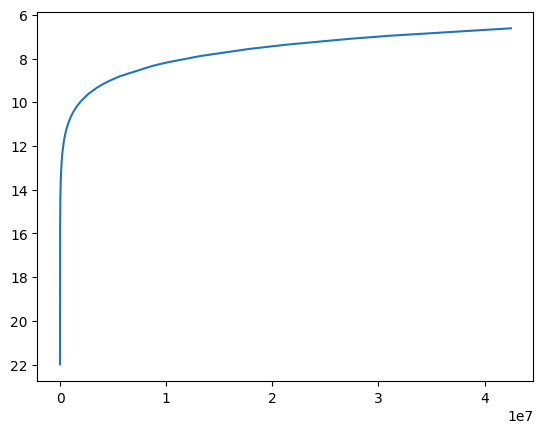

5.9420633345207285 6.23553304074723


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("gaiaTestData.csv")
maxidx = [data["phot_g_mean_flux"].idxmax()]
maxrow = data.loc[maxidx]
print(maxrow)
sorted_data = data.sort_values(by="phot_g_mean_flux",ascending = True)
X = sorted_data["phot_g_mean_flux"]
Y = sorted_data['phot_g_mean_mag']

fig, ax = plt.subplots()
ax.plot(X,Y)
ax.invert_yaxis()
plt.show()

# BP flux:
m_0_BP = 2.5*np.log10(sorted_data["phot_bp_mean_flux"])
average_BP = np.mean(m_0_BP)
#RP flux
m_0_RP = 2.5*np.log10(sorted_data["phot_rp_mean_flux"])
average_RP = np.mean(m_0_RP)

print(average_BP,average_RP)

## 6.10

In [44]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.table import Table

simple_query = """
SELECT
source_id, ra, dec, parallax, parallax_error, 
phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax >10
    AND parallax/parallax_error > 5
    AND radial_velocity IS NOT NULL
    AND phot_g_mean_mag < 15
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
"""
job = Gaia.launch_job(simple_query)
results = job.get_results()

dataframe = results.to_pandas()
tabledata = Table.from_pandas(dataframe)
tabledata.write("astroquery_gaia.fits",format="fits",overwrite=True)
print(tabledata)

/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.11.909) or chardet (4.0.0)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


    SOURCE_ID             ra         ... phot_bp_mean_mag phot_rp_mean_mag
----------------- ------------------ ... ---------------- ----------------
  774472798501120  46.75561090023727 ...        10.144306         9.175891
 1551896238772736  43.62998580035349 ...         15.54997        13.082512
 2063134785939840 43.695510361432824 ...         9.021275          8.17813
 3970886243752832  47.90468683305139 ...        16.178928        13.354075
 4769135981110528 42.724095982467844 ...         9.193995         8.430541
 5384171002266496  43.29235769895554 ...        12.665766        11.216251
 5403691629259136  43.21354566591454 ...        16.254227        13.707308
              ...                ... ...              ...              ...
23395378351883392  37.17738993292125 ...       10.9409685        10.003726
23439564975211392  36.94899451133908 ...       14.9555025        12.705171
23668916228857216 35.003904514924855 ...        15.441756        13.025999
25041862654548096  39.844

In [4]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
sp = SDSS.get_spectra(matches=xid)

flux = sp["flux"].data
loglength = sp["loglam"].data
wavelength = np.logspace(loglength,base=10)
z = 0.0038
rest = wavelength/(z+1)

fig, (ax1,ax2) = plt.subplots(2,1)
ax1.plot(rest, flux)
ax1.set_xlabel("Rest-frameWavelength ($\mathring{A}$)")
ax1.set_ylabel("Flux")
ax1.set_title("rest spectrum")

# for the wavelength between 6450 and 6650 i can use a mask:
mask = (rest>=6450) & (rest <=6650)
rest_toplot,flux_toplot = rest[mask], flux[mask]
ax2.plot(rest_toplot,flux_toplot)
ax2.set_xlabel("Rest-frameWavelength ($\mathring{A}$)")
ax2.set_ylabel("Flux")
ax2.set_title("Zoomed in")

plt.show()

#Draw vertical lines for H
# lines in both frames. Label them and show with legend.
#Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H
# line.
#An example plot is shown below.
#Calculating the velocity indicated by the difference between the two wavelengths.
#Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

ModuleNotFoundError: No module named 'astroquery'

## 6.14

In [28]:

class Fibonacci:
    def __init__(self, term, divisor):
        self.term = term
        self.divisor = divisor
        
    def fibo(self):
        n = 0
        num1 = 0
        num2 = 1
        fibo=0
        feblist = []
        for n in range(self.term):
            #mistake some where
            if n<2:
                fibo=fibo+num2
            else:
                fibo=num1+num2
            num1=num2
            num2=fibo
            n+=1
            feblist.append(fibo)
      
        return fibo, feblist

    def divideM(self):
        nums = []
        for number in feblist:
        
            if number%self.divisor == 0:
                nums.append(number)
        
        return nums
  
userval = input("Enter N: ")
userdiv = input("Enter M: ")
nth = int(userval)
div = int(userdiv)
fibo1,feblist= Fibonacci().fibo(nth)
nums= Fibonacci().divideM(nth,div)
print(fibo1)
print(nums)

Enter N: 100
Enter M: 7
573147844013817084101
[21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
